# Look for left-right movements

In [1]:
import numpy as np
import pandas as pd
import copy

#df_1d = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/smoothed_timecourse_gaze.csv')
df_1d = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/20240827_timecourse_df.csv')


# change name of 'mean_gaze_x' to  'mean_x'
df_1d = df_1d.rename(columns={'mean_gaze_x': 'mean_x'})

# change name of 'mean_gaze_y' to 'mean_y'
df_1d = df_1d.rename(columns={'mean_gaze_y': 'mean_y'})

# keep only conditions 2 and 3
df_1d = df_1d[df_1d['condition'].isin([2,3])]

# keep only columns: sub, condition, mean_x, mean_y, time_rounded_relative
df_1d = df_1d[['sub', 'condition', 'mean_x', 'mean_y', 'time_rounded_relative']]

# rename time_rounded_relative to time
df_1d = df_1d.rename(columns={'time_rounded_relative': 'time'})

# round time_rounded_relative to 3 decimal places
df_1d['time'] = df_1d['time'].apply(lambda x: round(x, 3))

# order by: subject, time, condition
df_1d = df_1d.sort_values(by=['sub', 'time', 'condition'])

# reset index
df_1d = df_1d.reset_index(drop=True)

# smooth mean_x and mean_y within each subject and condition using a gaussian kernel
def smooth_mean(df, sigma, window_size=50):
    df['mean_x'] = df.groupby(['sub', 'condition'])['mean_x'].transform(lambda x: x.rolling(window=window_size, win_type='gaussian', min_periods=1, center=True).mean(std=sigma))
    df['mean_y'] = df.groupby(['sub', 'condition'])['mean_y'].transform(lambda x: x.rolling(window=window_size, win_type='gaussian', min_periods=1, center=True).mean(std=sigma))
    return df

df_1d = smooth_mean(df_1d, sigma=4.25, window_size=20) # roughly corresponds to a window size of 10ms as due to sigma=4.25, the kernel is 10ms wide

# how much further right do we go for 2 than 3? 
# need to check if 2-3 > 0
# if so, 2 is further right
# if not, 3 is further right

df_2 = copy.deepcopy(df_1d[df_1d['condition'] == 2])
# drop index
df_2 = df_2.reset_index(drop=True)
df_3 = df_1d[df_1d['condition'] == 3]
# drop index
df_3 = df_3.reset_index(drop=True)

change_x = df_2['mean_x'] - df_3['mean_x']
change_y = df_2['mean_y'] - df_3['mean_y']

change_x = change_x.reset_index(drop=True)
change_y = change_y.reset_index(drop=True)

df_2['change_x'] = change_x
df_2['change_y'] = change_y

df_2 = df_2.drop(['mean_x', 'mean_y', 'condition'], axis=1)

df_change = df_2


# remove sub-09

df_change = df_change[df_change['sub'] != 'sub-09']

# remove any nans

df_change = df_change.dropna()

# order by subject and time
df_change = df_change.sort_values(by=['sub', 'time'])

df_change.head()

,sub,time,change_x,change_y
0,sub-01,-0.501,0.000701,0.000756
1,sub-01,-0.500,0.000714,0.000767
2,sub-01,-0.499,0.000727,0.000781
3,sub-01,-0.498,0.000731,0.000812
4,sub-01,-0.497,0.000734,0.000846


In [2]:
# number of subjects?
subs = df_change['sub'].unique()
n_subs = len(subs)
n_subs

43

In [3]:
subs

array(['sub-01', 'sub-07', 'sub-10', 'sub-11', 'sub-12', 'sub-13',
       'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-19', 'sub-21',
       'sub-22', 'sub-23', 'sub-24', 'sub-25', 'sub-26', 'sub-27',
       'sub-28', 'sub-29', 'sub-30', 'sub-31', 'sub-34', 'sub-36',
       'sub-37', 'sub-38', 'sub-39', 'sub-42', 'sub-43', 'sub-46',
       'sub-47', 'sub-48', 'sub-49', 'sub-51', 'sub-52', 'sub-53',
       'sub-55', 'sub-56', 'sub-58', 'sub-59', 'sub-60', 'sub-61',
       'sub-62'], dtype=object)

In [46]:
from mne.stats import spatio_temporal_cluster_1samp_test, ttest_ind_no_p


# data should be subject x space x time

# get data for corr_2d

data_change = df_change.pivot(index='sub', columns='time', values='change_x')

# turn into np array of shape sub x time x 1

data_change = data_change.values.reshape(data_change.shape[0], data_change.shape[1], 1)

# run cluster test
degf = data_change.shape[0] - 1
from scipy import stats

T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
                                                                     n_permutations=10000, 
                                                                     tail=1,
                                                                     threshold=None
                                                                     )

print(cluster_p_values_change)


# get timepoints for significant clusters

# get indices of clusters where p<0.05

sig_clusters_change = [i for i, p in enumerate(cluster_p_values_change) if p < 0.05]

# get timepoints for each sig cluster

timepoints_change = []

for cluster_change in sig_clusters_change:
    timepoints_change.append(clusters_change[cluster_change][0])

timepoints_change = [item for sublist in timepoints_change for item in sublist]


Using a threshold of 1.681952
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 14 clusters


/var/folders/yf/gwy8by0x6l56gb82wlwny7ym0000gn/T/ipykernel_4251/3468627426.py:18: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
100%|██████████| Permuting : 9999/9999 [00:08<00:00, 1239.96it/s]

[5.501e-01 6.991e-01 4.785e-01 4.146e-01 7.401e-01 7.189e-01 7.026e-01
 7.753e-01 4.667e-01 6.640e-01 5.507e-01 5.043e-01 1.000e-04 1.990e-02]


In [55]:
T_obs_change[30]

array([-0.78777493])

In [56]:
import numpy as np

# Set a significance threshold for p-values
significance_threshold = 0.05

# Identify the significant clusters based on p-values
significant_clusters_indices = np.where(cluster_p_values_change < significance_threshold)[0]

# Extract the t-values corresponding to those significant clusters
significant_t_values = []

# Loop through each significant cluster index and extract the corresponding t-value
for cluster_index in significant_clusters_indices:
    # Get the indices of the current cluster
    cluster_indices = clusters_change[cluster_index]
    
    # Extract the t-values for these indices from T_obs_change
    cluster_t_values = T_obs_change[cluster_indices]
    
    # Append the maximum t-value for each significant cluster (or you could average, depending on your approach)
    significant_t_values.append(np.max(cluster_t_values))  # or np.mean(cluster_t_values)
    
# Print the significant t-values
print("Significant t-values for clusters:")
print(significant_t_values)


Significant t-values for clusters:
[5.9915504715540235, 3.8280554185416853]


In [57]:
# print start and end timepoints for each sig cluster

for cluster_change in sig_clusters_change:
    print(clusters_change[cluster_change][0][0], clusters_change[cluster_change][0][-1])

    # print tval
    
    # print pval
    print(cluster_p_values_change[cluster_change])


1345 2278
0.0001
2373 2700
0.0199


In [35]:
df_change['change_x'] = df_change['change_x'].apply(lambda x: x*1080)

df_change

,sub,time,change_x,change_y
0,sub-01,-0.501,0.757409,0.000756
1,sub-01,-0.500,0.771530,0.000767
2,sub-01,-0.499,0.785053,0.000781
3,sub-01,-0.498,0.789358,0.000812
4,sub-01,-0.497,0.793070,0.000846
...,...,...,...,...
129043,sub-62,2.489,-1.179157,-0.001256
129044,sub-62,2.490,-1.165985,-0.001272
129045,sub-62,2.491,-1.179277,-0.001272
129046,sub-62,2.492,-1.240522,-0.001261


/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


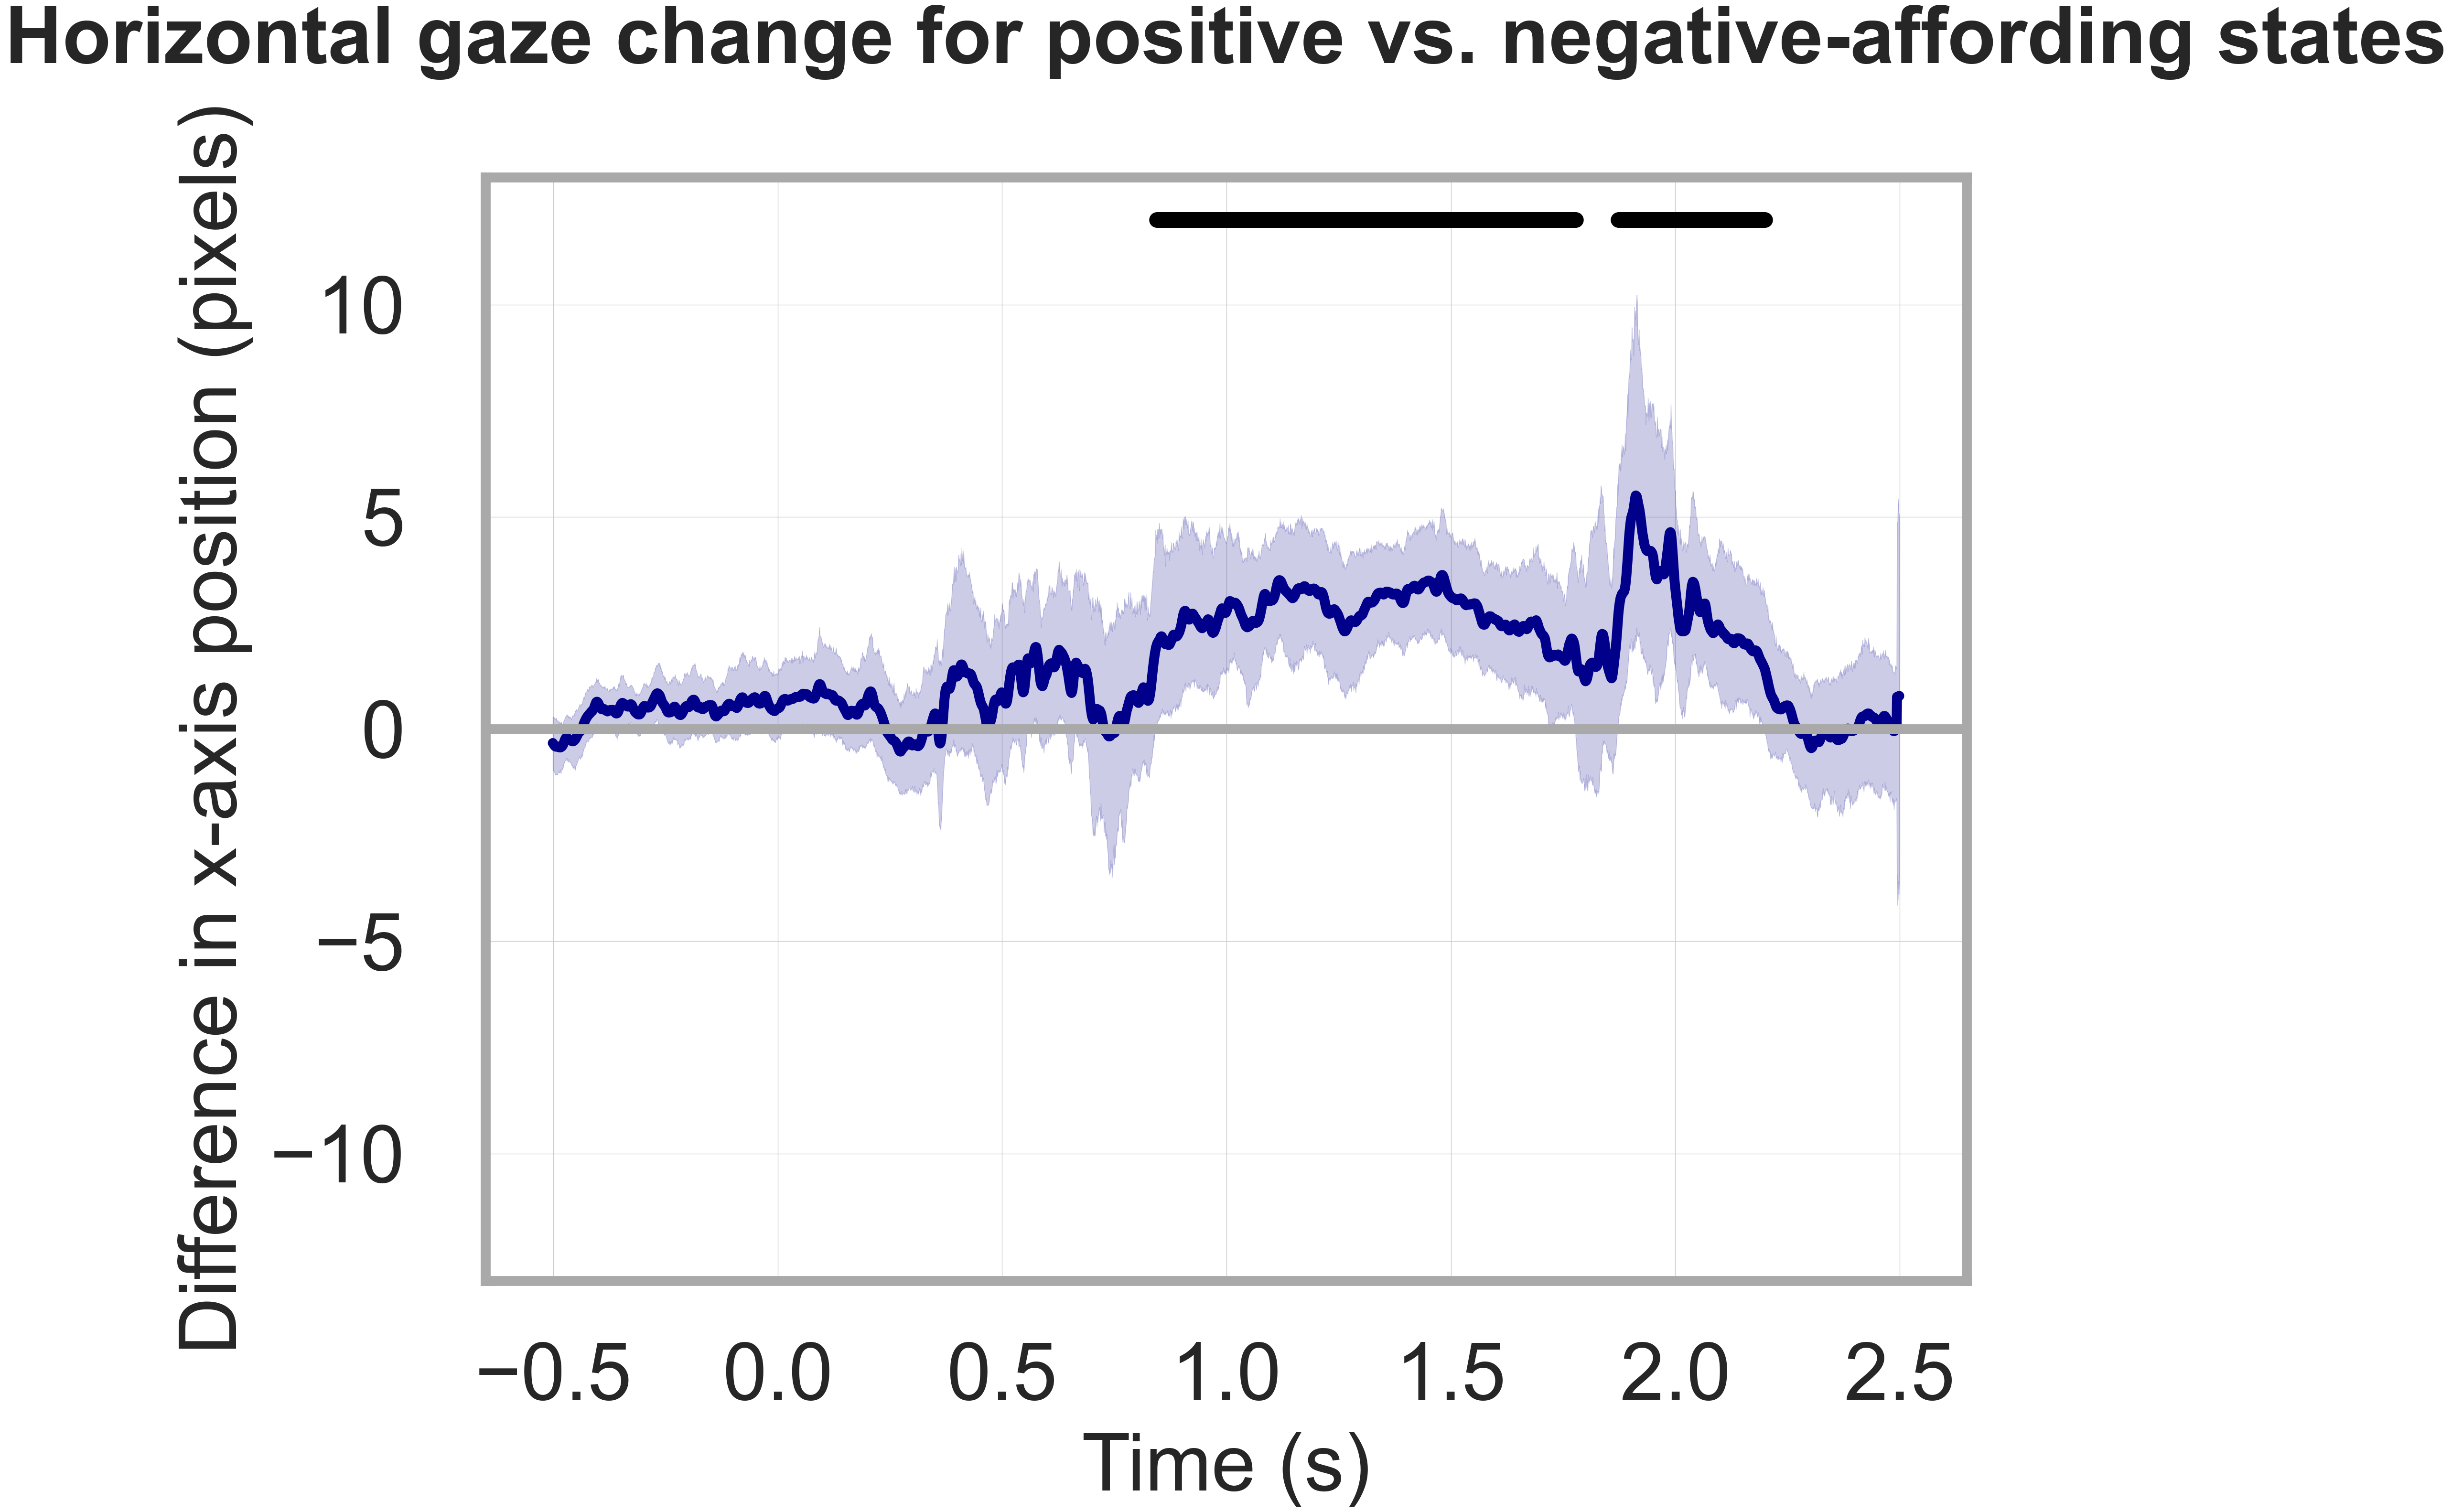

In [36]:

from matplotlib import pyplot as plt
import seaborn as sns

# multiply change_x by 1080
#df_change['change_x'] = df_change['change_x'].apply(lambda x: x*1080)

# take only every 10th row
#df_change = df_change.iloc[::10, :]

# set sns style as wgrid
sns.set(style='whitegrid')


# set plot size as 10*20
plt.figure(figsize=(40, 30))

# lineplot of cor_2d over time
ax = sns.lineplot(x='time', y='change_x', data=df_change, color='darkblue', linewidth=15)

# add a dark line at y=0
plt.axhline(0, color='darkgrey', linewidth=15)

# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)

# change x axis label to 'Trial group'
plt.xlabel('Time (s)', fontsize=120, labelpad=25)

# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)

# make y axis labels bigger
plt.yticks(fontsize=120)

# change y axis label to 'Performance'
plt.ylabel('Difference in x-axis position (pixels)', fontsize=120, labelpad=25)

# add title
plt.title('Horizontal gaze change for positive vs. negative-affording states', fontsize=120, y=1.1, fontweight='bold')


# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')


# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

for timepoint in timepoints_change:
    # plot a dot at y=1.1
    plt.scatter((timepoint/1000)-0.5, 12, color='black', s=500)

# set ylim as -10 to 13
plt.ylim(-13, 13)


plt.show()

In [58]:
# same for change y
# data should be subject x space x time
# get data for corr_2d
data_change = df_change.pivot(index='sub', columns='time', values='change_y')
# turn into np array of shape sub x time x 1
data_change = data_change.values.reshape(data_change.shape[0], data_change.shape[1], 1)
# run cluster test
degf = data_change.shape[0] - 1
from scipy import stats
T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
                                                                     n_permutations=10000, 
                                                                     tail=1,
                                                                     threshold=None
                                                                     )


print(cluster_p_values_change)
sig_clusters_change = [i for i, p in enumerate(cluster_p_values_change) if p < 0.05]
# get timepoints for each sig cluster
timepoints_change_y = []
for cluster_change in sig_clusters_change:
    timepoints_change_y.append(clusters_change[cluster_change][0])
timepoints_change_y = [item for sublist in timepoints_change_y for item in sublist]


Using a threshold of 1.681952
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 16 clusters


/var/folders/yf/gwy8by0x6l56gb82wlwny7ym0000gn/T/ipykernel_4251/3910144439.py:10: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
100%|██████████| Permuting : 9999/9999 [00:10<00:00,  943.36it/s]

[0.8654 0.5496 0.5107 0.018  0.6238 0.5318 0.8563 0.5231 0.1158 0.6497
 0.5673 0.8628 0.2854 0.8604 0.1962 0.5375]


In [59]:
import numpy as np

# Set a significance threshold for p-values
significance_threshold = 0.05

# Identify the significant clusters based on p-values
significant_clusters_indices = np.where(cluster_p_values_change < significance_threshold)[0]

# Extract the t-values corresponding to those significant clusters
significant_t_values = []

# Loop through each significant cluster index and extract the corresponding t-value
for cluster_index in significant_clusters_indices:
    # Get the indices of the current cluster
    cluster_indices = clusters_change[cluster_index]
    
    # Extract the t-values for these indices from T_obs_change
    cluster_t_values = T_obs_change[cluster_indices]
    
    # Append the maximum t-value for each significant cluster (or you could average, depending on your approach)
    significant_t_values.append(np.max(cluster_t_values))  # or np.mean(cluster_t_values)
    
# Print the significant t-values
print("Significant t-values for clusters:")
print(significant_t_values)


Significant t-values for clusters:
[3.168768811297824]


In [61]:
# print start and end timepoints for each sig cluster

for cluster_change in sig_clusters_change:
    print(clusters_change[cluster_change][0][0], clusters_change[cluster_change][0][-1])
    # print pval

    print(cluster_p_values_change[cluster_change])


# multiply change_x by 1080
df_change['change_y'] = df_change['change_y'].apply(lambda x: x*1080)


1639 1923
0.018


/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


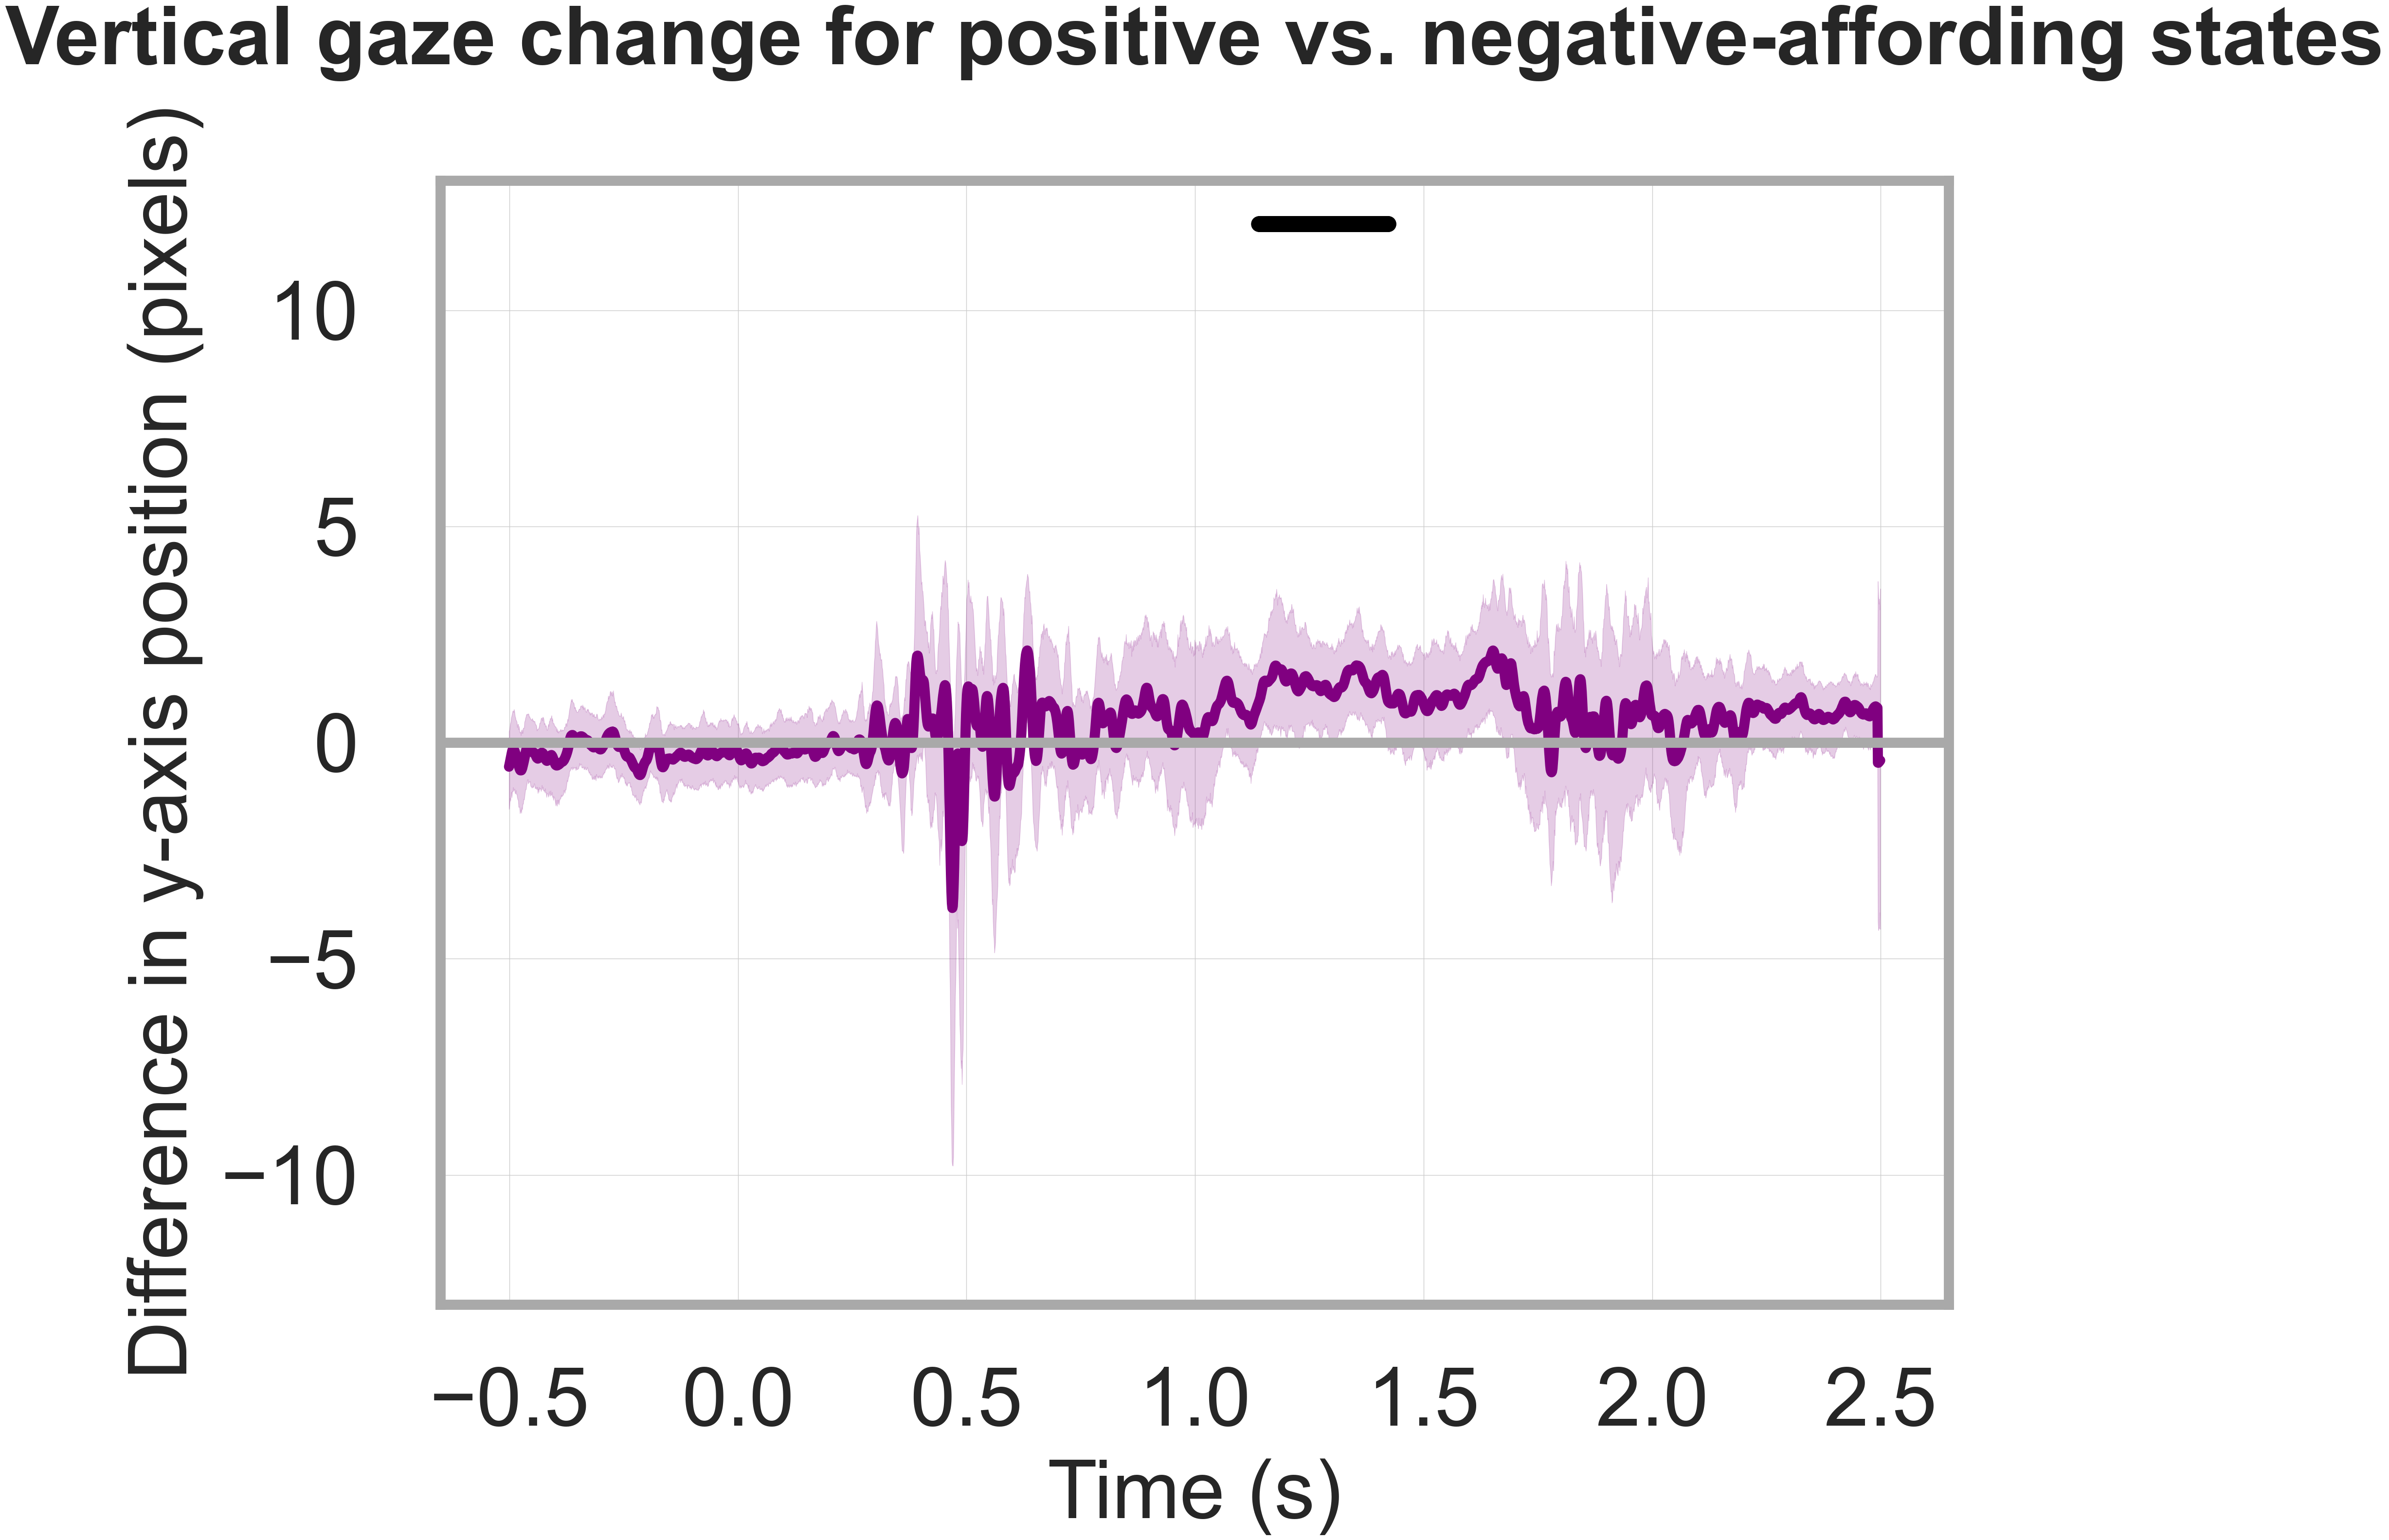

In [9]:

from matplotlib import pyplot as plt
import seaborn as sns

# take only every 10th row
#df_change = df_change.iloc[::10, :]

# set sns style as wgrid
sns.set(style='whitegrid')


# set plot size as 10*20
plt.figure(figsize=(40, 30))

# lineplot of cor_2d over time
ax = sns.lineplot(x='time', y='change_y', data=df_change, color='purple', linewidth=15)

# add a dark line at y=0
plt.axhline(0, color='darkgrey', linewidth=15)

# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)

# change x axis label to 'Trial group'
plt.xlabel('Time (s)', fontsize=120, labelpad=25)

# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)

# make y axis labels bigger
plt.yticks(fontsize=120)

# change y axis label to 'Performance'
plt.ylabel('Difference in y-axis position (pixels)', fontsize=120, labelpad=25)

# add title
plt.title('Vertical gaze change for positive vs. negative-affording states', fontsize=120, y=1.1, fontweight='bold')


# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')


# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

for timepoint in timepoints_change_y:
    # plot a dot at y=1.1
    plt.scatter((timepoint/1000)-0.5, 12, color='black', s=500)


# set ylim as -10 to 13
plt.ylim(-13, 13)

plt.show()

# Find center of cluster for corr_2D and take median corr value per subject in that time window 

In [9]:
# filter df by significant clusters in 2d condition, using indices in timepoints variable
# timepoints are indices of time column, so create list of times for these indices

#timepoints = df['time'].unique()[timepoints]

df_sig = df[df['time'].isin(timepoints)]

# sort by subject (not numerical)
df_sig = df_sig.sort_values(by='sub')

df_sig.head()


NameError: name 'df' is not defined

In [10]:
# take the median of corr_2d per subject
# group by subject and take median of corr_2d

df_sig_med = df_sig.groupby('sub').median()

# flatten the multiindex
df_sig_med = df_sig_med.reset_index()

# load in df from rdm_correlations.csv
df_rdm = pd.read_csv('/Users/alex/Documents/reasoning_memory/action_hippo/eyes/rdm_correlations_partial.csv')

# take only rows where sub is in df_sig_med['sub'], which is a column not an index
df_rdm = df_rdm[df_rdm['sub'].isin(df_sig_med['sub'])]


# take only rows where region is '7A-bilateral'
df_rdm = df_rdm[df_rdm['region'] == '7A-bilateral']

# take only rows where model is 'affordance'
df_rdm = df_rdm[df_rdm['model'] == 'affordance_magnitude']

# merge df_sig_med and df_rdm on sub
df_sig_med = df_sig_med.merge(df_rdm, on='sub')

# load in performance info from subject_performances_et.json
import json

with open('/Users/alex/Documents/reasoning_memory/action_hippo/eyes/subject_performances_et.json') as f:
    data_et_perf = json.load(f)

print(data_et_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_perf'] = [data_et_perf[sub] for sub in df_sig_med['sub']]

# same for subject_performances_all_trials.json
with open('/Users/alex/Documents/reasoning_memory/action_hippo/eyes/subject_performances_all_trials_et.json') as f:
    data_all_perf = json.load(f)

print(data_all_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_all_perf'] = [data_all_perf[sub] for sub in df_sig_med['sub']]

df_sig_med.head()


NameError: name 'df_sig' is not defined

In [172]:
# plot correlation between corr_2d and correlation

sns.scatterplot(x='corr_2d', y='et_all_perf', data=df_sig_med)

# run a correlation test
from scipy.stats import pearsonr

pearsonr(df_sig_med['corr_2d'], df_sig_med['et_all_perf'])

ValueError: Could not interpret value `corr_2d` for parameter `x`

# Same for x effect and y effect

In [22]:
df_change


,sub,time,change_x,change_y
0,sub-01,-0.501,0.757409,0.000756
1,sub-01,-0.500,0.771530,0.000767
2,sub-01,-0.499,0.785053,0.000781
3,sub-01,-0.498,0.789358,0.000812
4,sub-01,-0.497,0.793070,0.000846
...,...,...,...,...
129043,sub-62,2.489,-1.179157,-0.001256
129044,sub-62,2.490,-1.165985,-0.001272
129045,sub-62,2.491,-1.179277,-0.001272
129046,sub-62,2.492,-1.240522,-0.001261


In [11]:
timepoints_change

[1345,
 1346,
 1347,
 1348,
 1349,
 1350,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1357,
 1358,
 1359,
 1360,
 1361,
 1362,
 1363,
 1364,
 1365,
 1366,
 1367,
 1368,
 1369,
 1370,
 1371,
 1372,
 1373,
 1374,
 1375,
 1376,
 1377,
 1378,
 1379,
 1380,
 1381,
 1382,
 1383,
 1384,
 1385,
 1386,
 1387,
 1388,
 1389,
 1390,
 1391,
 1392,
 1393,
 1394,
 1395,
 1396,
 1397,
 1398,
 1399,
 1400,
 1401,
 1402,
 1403,
 1404,
 1405,
 1406,
 1407,
 1408,
 1409,
 1410,
 1411,
 1412,
 1413,
 1414,
 1415,
 1416,
 1417,
 1418,
 1419,
 1420,
 1421,
 1422,
 1423,
 1424,
 1425,
 1426,
 1427,
 1428,
 1429,
 1430,
 1431,
 1432,
 1433,
 1434,
 1435,
 1436,
 1437,
 1438,
 1439,
 1440,
 1441,
 1442,
 1443,
 1444,
 1445,
 1446,
 1447,
 1448,
 1449,
 1450,
 1451,
 1452,
 1453,
 1454,
 1455,
 1456,
 1457,
 1458,
 1459,
 1460,
 1461,
 1462,
 1463,
 1464,
 1465,
 1466,
 1467,
 1468,
 1469,
 1470,
 1471,
 1472,
 1473,
 1474,
 1475,
 1476,
 1477,
 1478,
 1479,
 1480,
 1481,
 1482,
 1483,
 1484,
 1485,
 1486,
 1487,

In [12]:
# this is for x

timepoints = df_change['time'].unique()[timepoints_change]

# print timepoints
print(timepoints)

df_sig_change = df_change[df_change['time'].isin(timepoints)]

# sort by time and subject (not numerical)
df_sig_change = df_sig_change.sort_values(by=['sub', 'time'])

# remove method column
#df_sig_change = df_sig_change.drop('method', axis=1)

df_sig_change.head()


[0.844 0.845 0.846 ... 2.197 2.198 2.199]


,sub,time,change_x,change_y
1345,sub-01,0.844,4.056837,0.002913
1346,sub-01,0.845,4.165081,0.002830
1347,sub-01,0.846,4.235064,0.002750
1348,sub-01,0.847,4.265330,0.002695
1349,sub-01,0.848,4.287591,0.002668


In [22]:
# take the median of corr_2d per subject
# group by subject and take median of corr_2d

df_sig_med = df_sig_change.groupby('sub').median()

# flatten the multiindex
df_sig_med = df_sig_med.reset_index()

# load in df from rdm_correlations.csv
df_rdm = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/rdm_correlations_partial.csv')

# take only rows where sub is in df_sig_med['sub'], which is a column not an index
df_rdm = df_rdm[df_rdm['sub'].isin(df_sig_med['sub'])]


# take only rows where region is '7A-bilateral'
df_rdm = df_rdm[df_rdm['region'] == '7A-bilateral']

# take only rows where model is 'affordance'
df_rdm = df_rdm[df_rdm['model'] == 'affordance_magnitude']

# merge df_sig_med and df_rdm on sub
df_sig_med = df_sig_med.merge(df_rdm, on='sub')


# load in performance info from subject_performances_et.json
import json

with open('/Users/alex/Documents/action_hippo/action_hippo/eyes/subject_performances_et.json') as f:
    data_et_perf = json.load(f)

print(data_et_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_perf'] = [data_et_perf[sub] for sub in df_sig_med['sub']]

# same for subject_performances_all_trials.json
with open('/Users/alex/Documents/action_hippo/action_hippo/eyes/subject_performances_all_trials_et.json') as f:
    data_all_perf = json.load(f)

print(data_all_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_all_perf'] = [data_all_perf[sub] for sub in df_sig_med['sub']]

df_sig_med.head()

{'sub-31': 0.8518518518518519, 'sub-46': 0.8148148148148148, 'sub-09': 0.8421052631578947, 'sub-03': 0.4745762711864407, 'sub-22': 0.7741935483870968, 'sub-55': 0.7301587301587301, 'sub-28': 0.8888888888888888, 'sub-10': 0.9047619047619048, 'sub-17': 0.6666666666666666, 'sub-60': 0.9032258064516129, 'sub-52': 0.8095238095238095, 'sub-25': 0.7868852459016393, 'sub-58': 0.603448275862069, 'sub-04': 0.7708333333333334, 'sub-41': 0.7884615384615384, 'sub-36': 0.54, 'sub-45': 0.9354838709677419, 'sub-32': 0.7142857142857143, 'sub-38': 0.6491228070175439, 'sub-56': 0.5901639344262295, 'sub-21': 0.8, 'sub-19': 0.7457627118644068, 'sub-13': 0.7966101694915254, 'sub-14': 0.6862745098039216, 'sub-26': 0.4827586206896552, 'sub-51': 0.7619047619047619, 'sub-07': 0.984375, 'sub-35': 0.6, 'sub-42': 0.7413793103448276, 'sub-48': 0.6363636363636364, 'sub-05': 0.7719298245614035, 'sub-37': 0.875, 'sub-40': 0.9322033898305084, 'sub-61': 0.7457627118644068, 'sub-16': 0.7090909090909091, 'sub-59': 0.91935

,sub,time,change_x,change_y,model,region,correlation,performance,mean_rdm_value,32_rdm_value,et_perf,et_all_perf
0,sub-01,1.4745,4.122819,0.002920,affordance_magnitude,7A-bilateral,0.355111,0.976562,114.849349,152.186754,0.849057,0.703125
1,sub-07,1.4745,7.005159,0.002288,affordance_magnitude,7A-bilateral,0.777770,1.000000,176.753180,125.047996,0.984375,0.984375
2,sub-10,1.4745,2.294441,0.001186,affordance_magnitude,7A-bilateral,0.512566,0.971963,92.427869,71.006605,0.904762,0.890625
3,sub-11,1.4745,13.577737,-0.006901,affordance_magnitude,7A-bilateral,0.355111,0.876033,75.714583,-28.267958,0.770492,0.734375
4,sub-12,1.4745,5.086321,-0.000930,affordance_magnitude,7A-bilateral,0.077075,0.975806,167.735161,209.949224,0.661017,0.609375


In [14]:
import copy
df_single_test_corr = copy.deepcopy(df_sig_med[(df_sig_med['region'] == 'Entorhinal-right')& (df_sig_med['model'] == 'affordance') & (df_sig_med['mean_rdm_value'] >0)])
from scipy.stats import ttest_1samp
corr_aff = df_single_test_corr['correlation'].to_list()
change_x_subset = df_single_test_corr['change_x'].to_list()
from scipy.stats import spearmanr
spearmanr(corr_aff, change_x_subset)

SignificanceResult(statistic=-0.06234367019095656, pvalue=0.7671937943999079)

In [15]:
df_single_test_corr

,sub,time,change_x,change_y,model,region,correlation,performance,mean_rdm_value,32_rdm_value,et_perf,et_all_perf
0,sub-01,1.4745,4.122819,0.002920,affordance,Entorhinal-right,0.384953,0.976562,15.092949,36.606171,0.849057,0.703125
7,sub-07,1.4745,7.005159,0.002288,affordance,Entorhinal-right,0.308880,1.000000,42.459915,67.448838,0.984375,0.984375
21,sub-11,1.4745,13.577737,-0.006901,affordance,Entorhinal-right,-0.199738,0.876033,32.411064,47.517959,0.770492,0.734375
28,sub-12,1.4745,5.086321,-0.000930,affordance,Entorhinal-right,0.458145,0.975806,7.380833,50.739520,0.661017,0.609375
56,sub-16,1.4745,3.803898,-0.001805,affordance,Entorhinal-right,-0.201432,0.925000,19.149202,25.896532,0.709091,0.609375
84,sub-22,1.4745,0.272625,-0.003459,affordance,Entorhinal-right,0.458145,0.754098,28.309507,57.194984,0.774194,0.750000
91,sub-23,1.4745,0.097142,0.000532,affordance,Entorhinal-right,-0.416819,0.669643,25.987870,0.598817,0.491803,0.468750
112,sub-26,1.4745,-1.942159,0.006617,affordance,Entorhinal-right,-0.143841,0.834951,15.775493,5.662204,0.482759,0.437500
126,sub-28,1.4745,3.116579,-0.001271,affordance,Entorhinal-right,-0.180185,0.889831,17.490073,13.473906,0.888889,0.875000
133,sub-29,1.4745,10.725927,-0.004669,affordance,Entorhinal-right,-0.146333,0.966942,10.402540,-1.403513,0.790323,0.765625


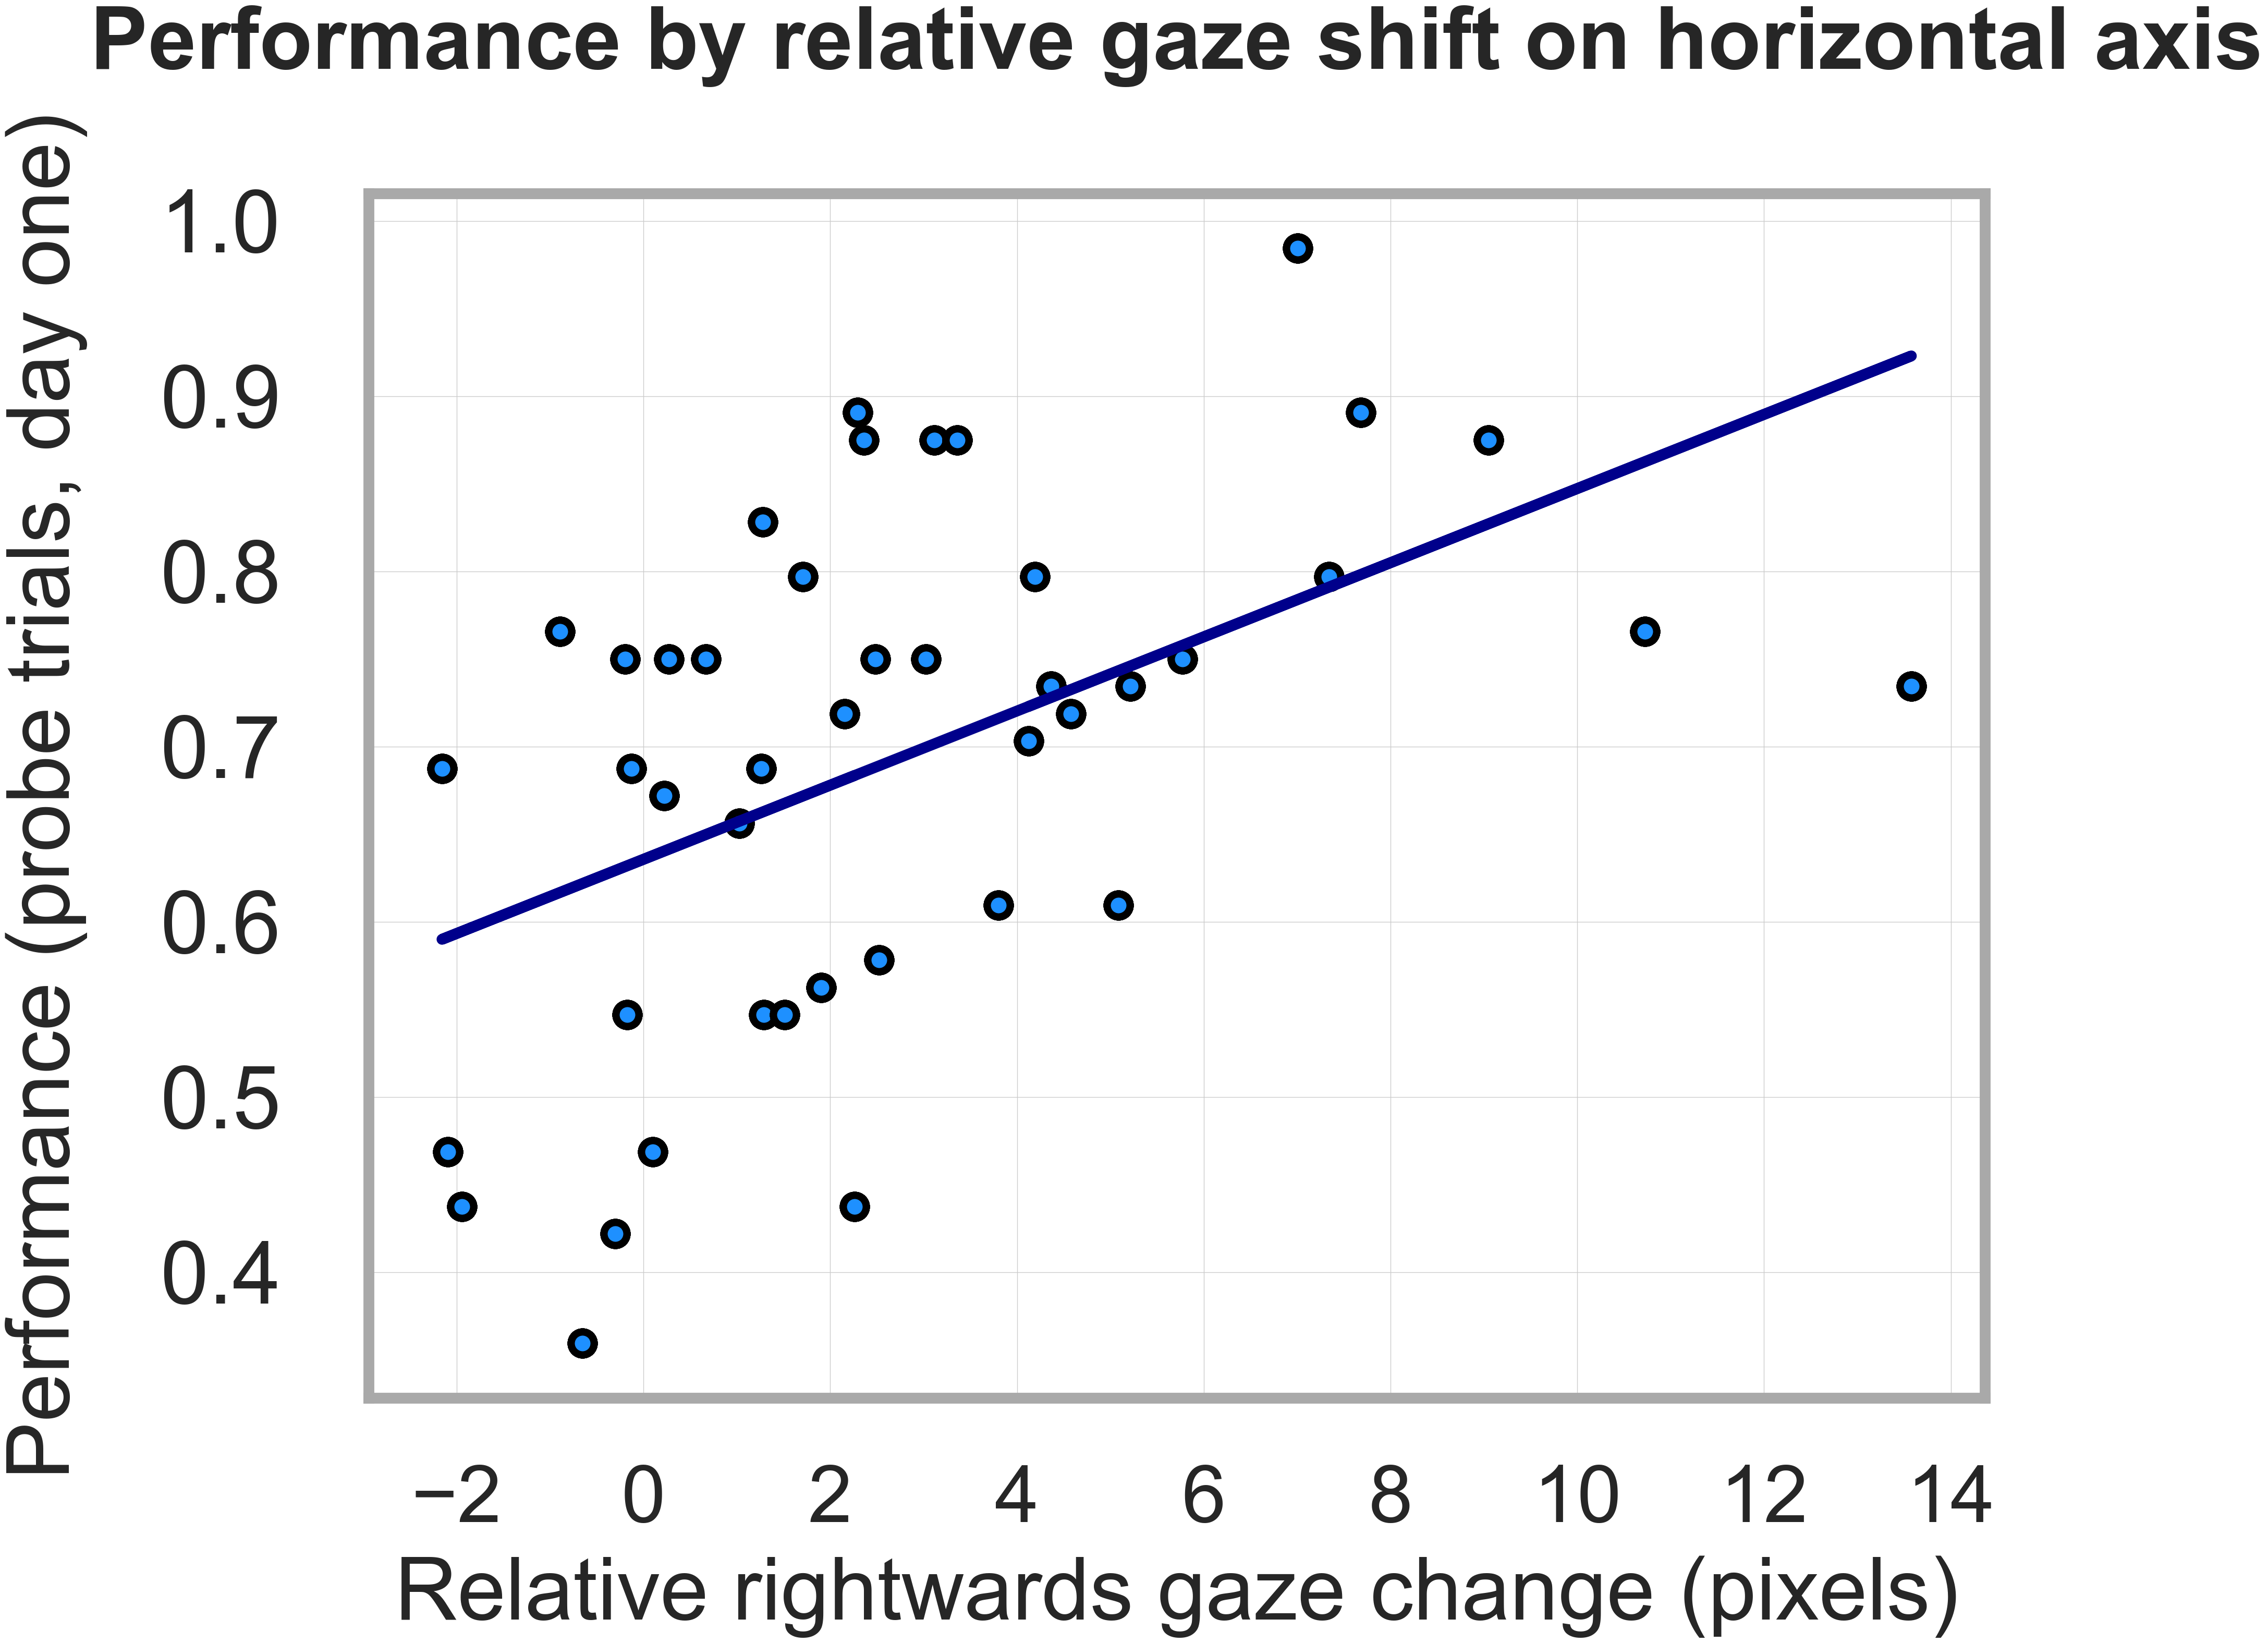

In [16]:
# plot correlation between change_x and correlation


# add regression line
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt


# make this plot nicer

# set sns style as wgrid
sns.set(style='whitegrid')


# set plot size as 10*20
plt.figure(figsize=(40, 30))


# multiply change_x by 1080 to get pixels
#df_sig_med['change_x'] = df_sig_med['change_x'].apply(lambda x: x/1080)

# add y label and x label
plt.ylabel('Performance during eyetracking, day 1', fontsize=30)
plt.xlabel('Change in x position (pixels)', fontsize=30)

# add a title, size 30 and not right next to plot, Change in x position vs performance during eyetracking
plt.title('Change in x position vs performance during eyetracking', pad=20, fontsize=30)

# scatterplot of change_x over time
ax = sns.scatterplot(x='change_x', y='et_all_perf', data=df_sig_med, color='darkblue', s=1000)

x = df_sig_med['change_x']
y = df_sig_med['et_all_perf']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

line = slope*x+intercept

plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept), linewidth=15)

# make line dark grey
plt.gca().lines[0].set_color('darkblue')

# make points dodgerblue with darkgrey edge
plt.gca().collections[0].set_color('dodgerblue')
plt.gca().collections[0].set_edgecolor('black')
# make points bigger

# make edges thicker
plt.gca().collections[0].set_linewidth(10)
# make titles and labels bigger

# set sns style as wgrid
sns.set(style='whitegrid')


# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)

# change x axis label to 'Trial group'
plt.xlabel('Relative rightwards gaze change (pixels)', fontsize=120, labelpad=25)

# make x axis labels bigger
plt.xticks(fontsize=110, y=-0.05)

# make y axis labels bigger
plt.yticks(fontsize=120)

# change y axis label to 'Performance'
plt.ylabel('Performance (probe trials, day one)', fontsize=120, labelpad=100)

# add title
plt.title('Performance by relative gaze shift on horizontal axis', fontsize=120, y=1.1, fontweight='bold')


# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')


# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

plt.show()

In [115]:
from scipy.stats import pearsonr

pearsonr(df_sig_med['et_all_perf'], df_sig_med['change_y'])

PearsonRResult(statistic=0.0830303872766892, pvalue=0.5965707791125965)

In [20]:
df_sig_med

,sub,time,change_x,change_y,model,region,correlation,performance,mean_rdm_value,32_rdm_value,et_perf,et_all_perf
0,sub-01,1.4745,4.122819,0.002920,affordance,7A-bilateral,0.493610,0.976562,114.849349,152.186754,0.849057,0.703125
1,sub-07,1.4745,7.005159,0.002288,affordance,7A-bilateral,-0.201432,1.000000,176.753180,125.047996,0.984375,0.984375
2,sub-10,1.4745,2.294441,0.001186,affordance,7A-bilateral,0.354660,0.971963,92.427869,71.006605,0.904762,0.890625
3,sub-11,1.4745,13.577737,-0.006901,affordance,7A-bilateral,-0.493610,0.876033,75.714583,-28.267958,0.770492,0.734375
4,sub-12,1.4745,5.086321,-0.000930,affordance,7A-bilateral,0.708024,0.975806,167.735161,209.949224,0.661017,0.609375
5,sub-13,1.4745,5.212462,-0.000343,affordance,7A-bilateral,-0.493610,0.898148,84.633524,19.672343,0.796610,0.734375
6,sub-14,1.4745,1.286570,0.001224,affordance,7A-bilateral,0.355706,0.915094,38.224588,82.043845,0.686275,0.546875
7,sub-15,1.4745,2.360220,0.003388,affordance,7A-bilateral,0.493610,0.944000,120.094899,124.397310,0.903226,0.875000
8,sub-16,1.4745,3.803898,-0.001805,affordance,7A-bilateral,0.201432,0.925000,104.536055,85.295945,0.709091,0.609375
9,sub-17,1.4745,1.027373,0.001124,affordance,7A-bilateral,0.458145,0.944000,155.765975,155.207390,0.666667,0.656250


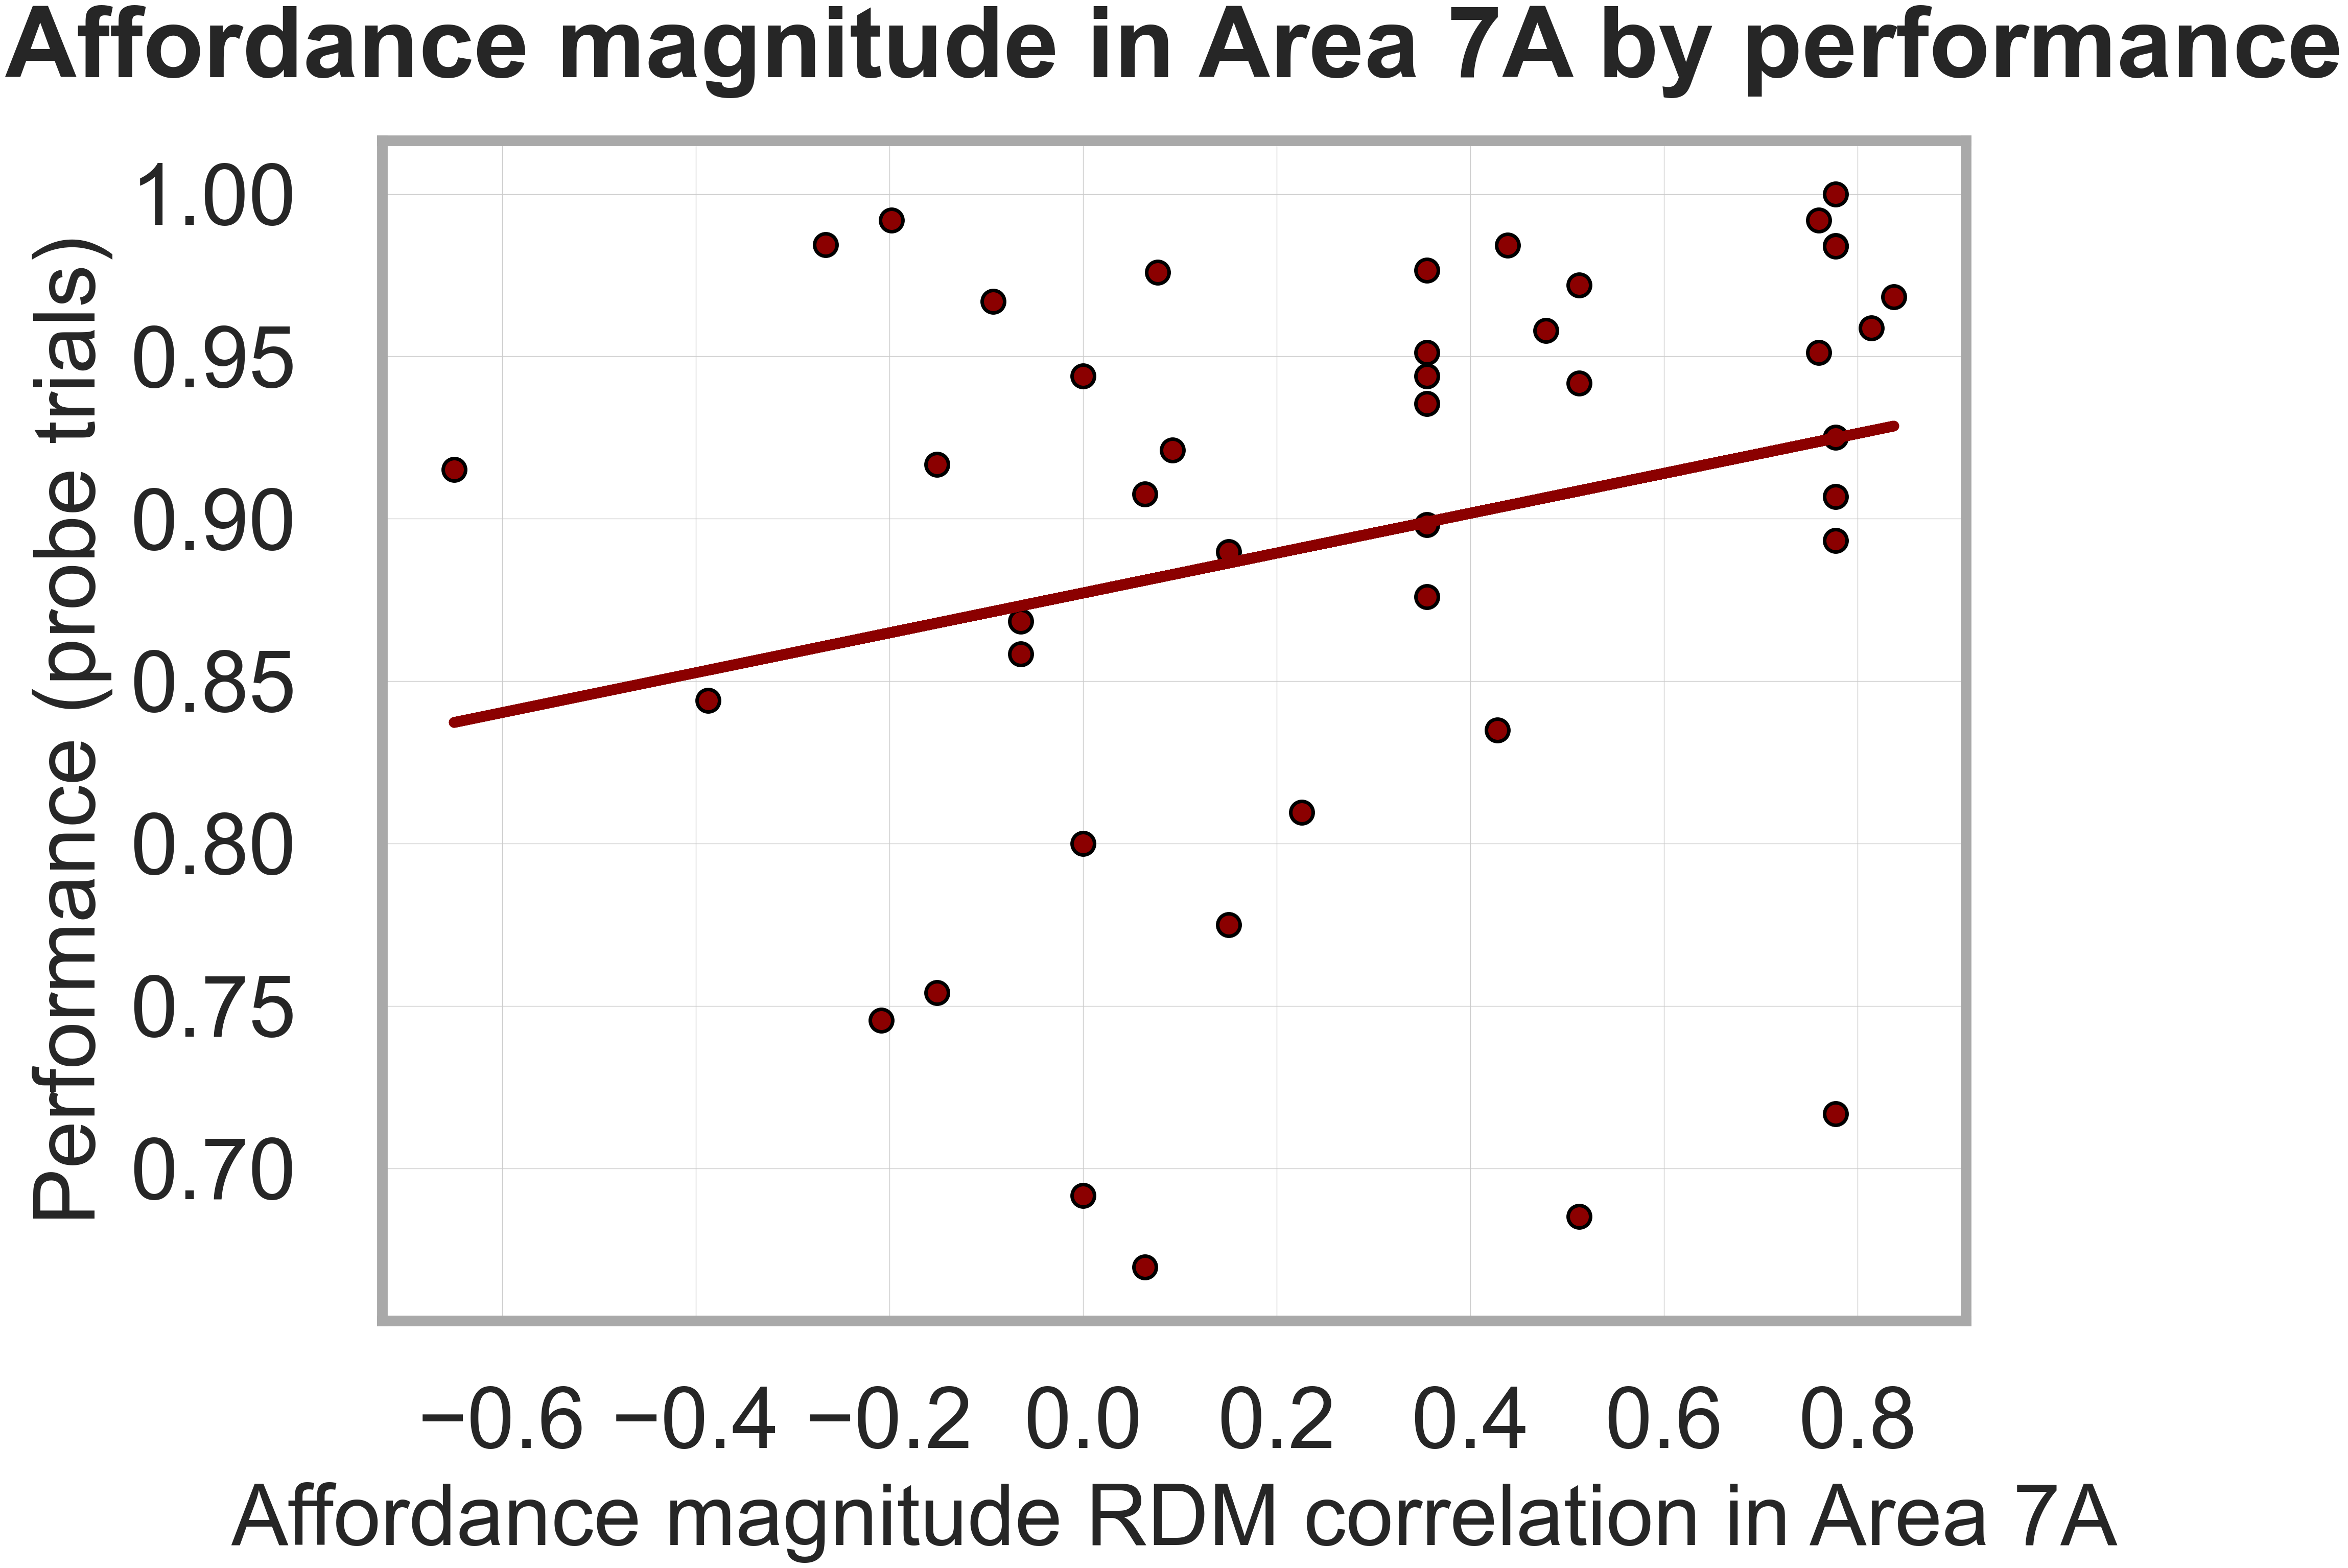

In [41]:
# same code as above but for correlation and performance
# plot correlation between change_x and correlation

import seaborn as sns
# add regression line
import numpy as np
from scipy.stats import linregress

# run a correlation test
from scipy.stats import pearsonr

pearsonr(df_sig_med['correlation'], df_sig_med['performance'])

# make this plot nicer

# set sns style as wgrid
#sns.set(style='whitegrid')

# set plot size as 10*20
f, ax = plt.subplots(figsize=(40, 30))

# scatterplot of change_x over time
ax=sns.scatterplot(x='correlation', y='performance', data=df_sig_med, color='darkred', s=1000)

x = df_sig_med['correlation']
y = df_sig_med['performance']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

line = slope*x+intercept

plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept), linewidth=15)

# make line dark grey
plt.gca().lines[0].set_color('darkred')

# make points dodgerblue with darkgrey edge
plt.gca().collections[0].set_edgecolor('black')

# make edges thicker
plt.gca().collections[0].set_linewidth(5)


# set sns style as wgrid
sns.set(style='whitegrid')


# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)

# change x axis label to 'Trial group'
plt.xlabel('Affordance magnitude RDM correlation in Area 7A', fontsize=120, labelpad=25)

# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)

# make y axis labels bigger
plt.yticks(fontsize=120)

# change y axis label to 'Performance'
plt.ylabel('Performance (probe trials)', fontsize=120, labelpad=25)

# add title
plt.title('Affordance magnitude in Area 7A by performance', fontsize=140, y=1.05, fontweight='bold')


# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')


# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

plt.show()

In [74]:
# correlate et_perf and et_all_perf

pearsonr(df_sig_med['et_perf'], df_sig_med['et_all_perf'])

PearsonRResult(statistic=0.9575873820488418, pvalue=4.8356855245479574e-21)